In [10]:
%load_ext autoreload
%autoreload 2

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.sandbox.stats.runs import runstest_1samp
from statsmodels.tsa.stattools import adfuller
from scipy.stats import anderson, wilcoxon
import statsmodels as stats
import pickle
import warnings
warnings.filterwarnings('ignore')
import importlib
import main_functions

importlib.reload(main_functions) 
from main_functions import *

### Проверим эффективность основных свечных паттернов на акциях на Татнефть на различных таймфреймах: 15 min, 30 min, 1h, 2h, 4h, D.


In [12]:
# Проверяем стратегии на множестве ТФ.
def backtest_strategies_multi_tf():
    """Функция позволяет проверить эффективность стратегии бычье поглощение на 7 основных таймфреймах.
    На выходе получаем большую сводную таблицу по результатам стратегии на всех таймфреймах.

    Args:
        data (pd.DataFrame): Подаем датафрейм с 1 минутным таймфреймом

    Returns:
        data (pd.DataFrame): Таблица с результатами всех стратегий
    """
    l = []
    # Перебираем все тф
    for a in [r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\TATN.txt']:
        data = pd.read_csv(a)
        for i in ['15 min', '30 min', '1h', '2h', '4h', 'D']:
            data_tm = good_dataframe(data, i)
            l.append(data_tm)
        
        all_strategy = []
        # Для каждого тф проверяем стратегию бычье поглощение
        for j in l:
            for func in [detection_bullish_engulfing_pattern, detection_bullish_harami_pattern, 
                        detection_break_in_the_clouds, detection_bullish_counterattack]:
                detection_data = func(shift_features_2_candle(j))
                result = data_prepare_for_statistics(detection_data)
                final_result = trade_statistics_bull(result)
                all_strategy.append(final_result)
        # Объединяем результат   
        combined_data = pd.concat(all_strategy, ignore_index=True)
    
    return combined_data

tatneft_result_strategies = backtest_strategies_multi_tf()
tatneft_result_strategies.head(3)

,ticker,strategy name,period,N,count of trades,profit factor,total percent return,R2,win_rate,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),capital curve net,capital curve without commission,profit percent net,percent profit without commission
0,TATN,bullish_engulfing_pattern,15 min,1,4730,0.675,-87.44,0.93,0.39,0.2,-0.2,1.0,211.9,time_N 2009-01-11 11:45:00 99906.000000 20...,time_N 2009-01-11 11:45:00 99946.000000 20...,time_N 2009-01-11 11:45:00 -0.00094 2009-01-...,time_N 2009-01-11 11:45:00 -0.00054 2009-01-...
1,TATN,bullish_engulfing_pattern,15 min,2,4730,0.780,-85.21,0.91,0.42,0.3,-0.3,1.0,206.2,time_N 2009-01-11 11:45:00 100282.000000 20...,time_N 2009-01-11 11:45:00 100322.000000 20...,time_N 2009-01-11 11:45:00 0.00282 2009-01-...,time_N 2009-01-11 11:45:00 0.00322 2009-01-...
2,TATN,bullish_engulfing_pattern,15 min,3,4602,0.818,-84.84,0.90,0.44,0.4,-0.4,1.0,217.3,time_N 2009-01-11 11:45:00 100353.000000 20...,time_N 2009-01-11 11:45:00 100393.000000 20...,time_N 2009-01-11 11:45:00 0.00353 2009-01-...,time_N 2009-01-11 11:45:00 0.00393 2009-01-...


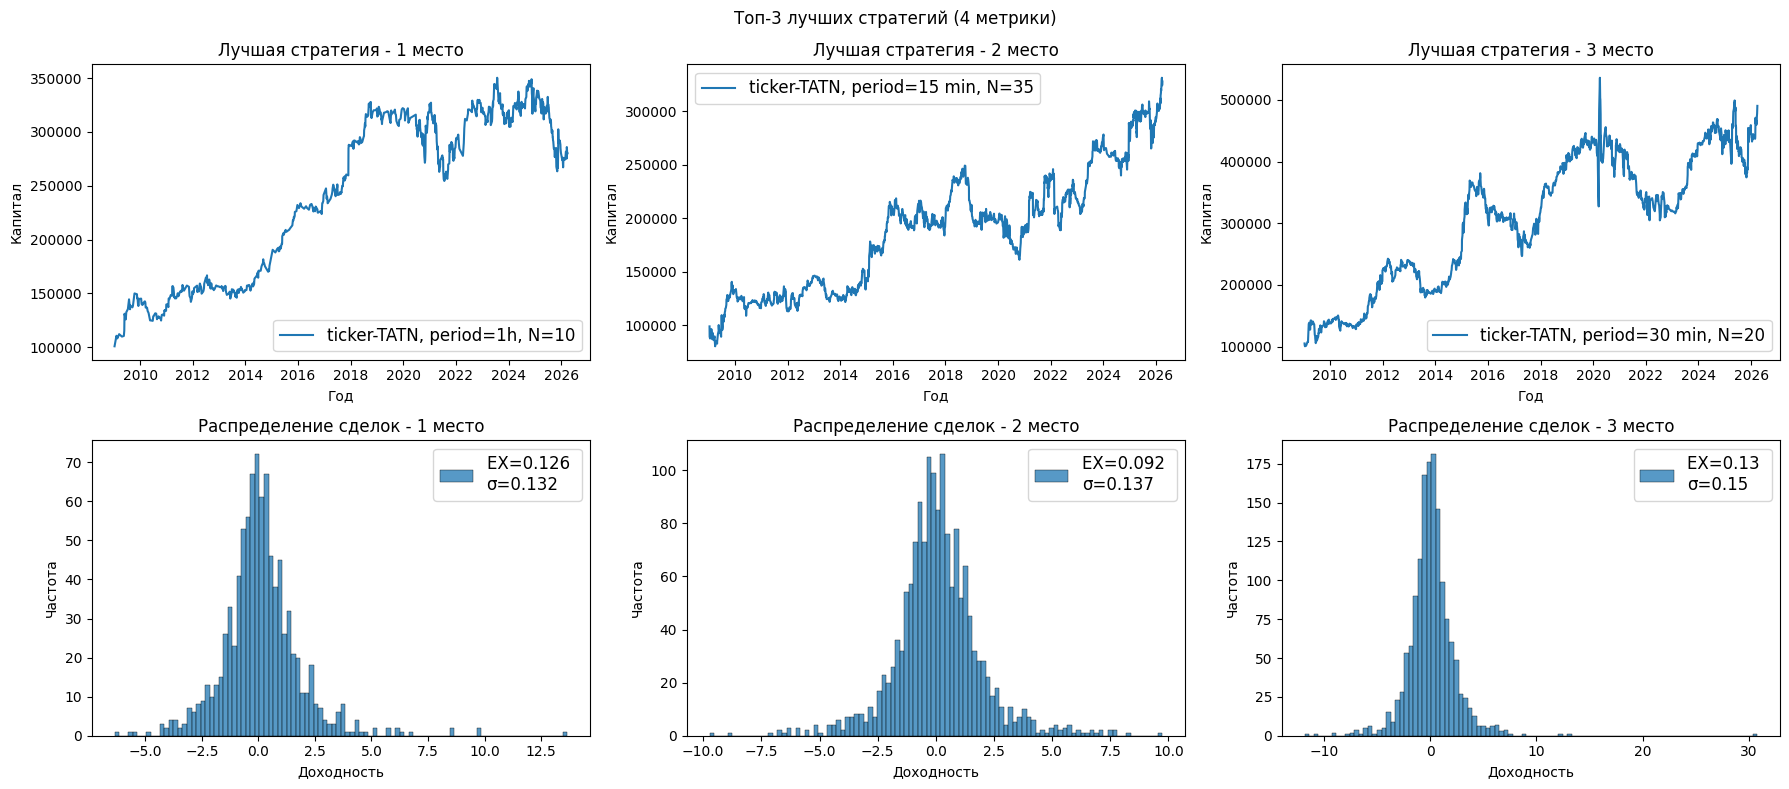

,ticker,strategy name,period,N,count of trades,profit factor,mean profit (%),mean loss (%),profit/loss ratio,max drawdown (%),total percent return,R2,win_rate
0,TATN,bullish_counterattack,1h,10,930,1.238,1.3,-1.1,1.18,27.0,180.11,0.70,0.50
1,TATN,bullish_counterattack,15 min,35,1593,1.151,1.4,-1.2,1.17,40.4,227.80,0.86,0.50
2,TATN,bullish_engulfing_pattern,30 min,20,1501,1.195,1.5,-1.4,1.07,52.0,390.19,0.78,0.52
3,TATN,break_in_the_clouds,15 min,35,1322,1.157,1.4,-1.3,1.08,36.3,173.01,0.71,0.51
4,TATN,break_in_the_clouds,15 min,40,1247,1.176,1.5,-1.4,1.07,45.0,201.62,0.72,0.51
5,TATN,break_in_the_clouds,15 min,45,1189,1.181,1.6,-1.5,1.07,54.1,210.33,0.71,0.52
6,TATN,break_in_the_clouds,15 min,50,1132,1.185,1.7,-1.6,1.06,50.3,227.40,0.65,0.52
7,TATN,bullish_engulfing_pattern,1h,15,919,1.172,1.8,-1.6,1.12,66.7,159.79,0.51,0.51


In [13]:
# Функция для первичного отбора стратегий
def compare_strategies(data):
    """Функция предназначена для сравнения полученных стратегий и выявления наилучших претендентов
    для дальнейшего анализа.

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
    Returns:
        data (pd.DaraFrame): Возвращаем отфильтрованный датафрейм со результатами стратегии на всех тайфреймах.
    """
    # Фильтрация стратегий
    data = data[(data['count of trades'] > 900) & (data['profit factor'] > 1.15) & (data['R2'] > 0.5)] # Ограничение по количеству сделок
    if data.shape[0] != 0:
        data['profit factor rank'] = data['profit factor'].rank() # Больше лучше
        data['R2 rank'] = data['R2'].rank() # Больше лучше
        data['profit/loss ratio rank'] = data['profit/loss ratio'].rank() # Больше лучше
        data['max drawdown rank'] = data['max drawdown (%)'].rank(ascending=False) # Меньше лучше
        data['best model'] = data['profit factor rank'] + data['R2 rank'] + data['profit/loss ratio rank'] + data['max drawdown rank']
        
        # Построение графиков 3 лучших стратегий
        
        data.sort_values('best model', ascending=False, inplace=True, ignore_index=True)
        if data.shape[0] >= 3:    
            # График
            fig, axes = plt.subplots(2, 3, figsize=(18, 8))
            plt.suptitle('Топ-3 лучших стратегий (4 метрики)')
            
            # Первые 3 графика
            sns.lineplot(data.loc[0, 'capital curve net'], ax=axes[0, 0], label=f'ticker-{data.loc[0, 'ticker']}, period={data.loc[0, 'period']}, N={data.loc[0, 'N']}');
            sns.lineplot(data.loc[1, 'capital curve net'], ax=axes[0, 1], label=f'ticker-{data.loc[1, 'ticker']}, period={data.loc[1, 'period']}, N={data.loc[1, 'N']}');
            sns.lineplot(data.loc[2, 'capital curve net'], ax=axes[0, 2], label=f'ticker-{data.loc[2, 'ticker']}, period={data.loc[2, 'period']}, N={data.loc[2, 'N']}');
            axes[0, 0].legend(fontsize=12)
            axes[0, 1].legend(fontsize=12)
            axes[0, 2].legend(fontsize=12)
            
            axes[0, 0].set_title('Лучшая стратегия - 1 место')
            axes[0, 1].set_title('Лучшая стратегия - 2 место')
            axes[0, 2].set_title('Лучшая стратегия - 3 место')
            axes[0, 0].set_ylabel('Капитал')
            axes[0, 1].set_ylabel('Капитал')
            axes[0, 2].set_ylabel('Капитал')
            axes[0, 0].set_xlabel('Год')
            axes[0, 1].set_xlabel('Год')
            axes[0, 2].set_xlabel('Год')
            
            # Вторые 3 графика
            sns.histplot(data.loc[0, 'profit percent net'] * 100, ax=axes[1, 0], bins=100, 
                            label=f'EX={np.round(np.mean(data.loc[0, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[0, "profit percent net"])),3)}');
            sns.histplot(data.loc[1, 'profit percent net'] * 100, ax=axes[1, 1], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[1, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[1, "profit percent net"])),3)}');
            sns.histplot(data.loc[2, 'profit percent net'] * 100, ax=axes[1, 2], bins=100,
                            label=f'EX={np.round(np.mean(data.loc[2, "profit percent net"]) * 100, 3)} \nσ={np.round(np.sqrt(np.std(data.loc[2, "profit percent net"])),3)}');
            axes[1, 0].legend(fontsize=12)
            axes[1, 1].legend(fontsize=12)
            axes[1, 2].legend(fontsize=12)
                
            axes[1, 0].set_title('Распределение сделок - 1 место')
            axes[1, 1].set_title('Распределение сделок - 2 место')
            axes[1, 2].set_title('Распределение сделок - 3 место')
            axes[1, 0].set_ylabel('Частота')
            axes[1, 1].set_ylabel('Частота')
            axes[1, 2].set_ylabel('Частота')
            axes[1, 0].set_xlabel('Доходность')
            axes[1, 1].set_xlabel('Доходность')
            axes[1, 2].set_xlabel('Доходность')
                
            plt.tight_layout()
            plt.show()
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))       
            return data
        else:
            data_new = data[['ticker', 'strategy name', 'period', 'N', 'count of trades',
            'profit factor', 'mean profit (%)', 'mean loss (%)', 'profit/loss ratio', 'max drawdown (%)', 'total percent return', 'R2', 'win_rate']]
            display(data_new.head(10))
            return data  
            
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')
    
res = compare_strategies(tatneft_result_strategies)

### После проверки более сотни различных стратегий мы можем видеть, что на акциях Татнефти паттерны дают неплохой результат. Проверим каждую стратегию.

ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК
ПАТТЕРН СЛУЧАЕН


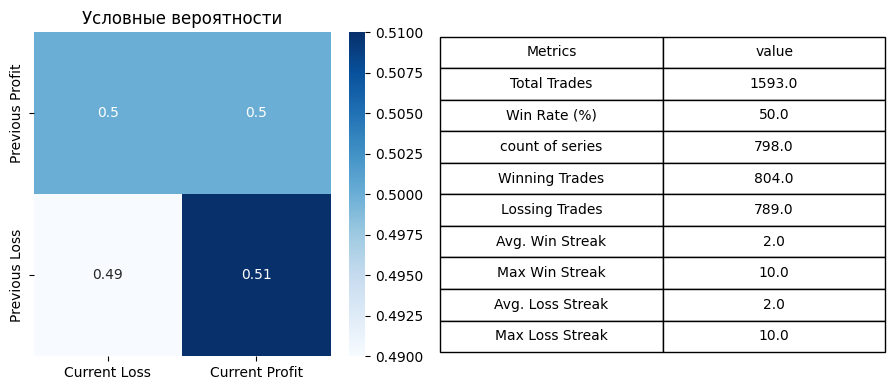

In [14]:
def run_analysis(lst):
    """Функция предназначена на статистического анализа торговой стратегии. Метрики, которые расчитываем:
    - Количество сделок всего, количество прибыльных/убыточных сделок
    - Количество серий (сколько раз был переход от прибыли к убытку и наоборот)
    - Средняя серия прибыльных/убыточных сделок
    - Максимальная серия прибыльных/убыточных сделок
    - Тест Вальда-Вольфовица для определения случайности в сериях сделок
    - Условные вероятности : P(W | W), P(W | L), P(L | W), P(L | L)

    Args:
        lst (list): Список чистых доходностей в %.

    Returns:
        Теловая карта с условными вероятностями и таблицу со всеми метриками.
    """
    if len(lst) > 0:
        lst_new = np.array(lst)
        lst_sign = (lst_new > 0).astype(int)
        n_win = np.sum(lst_sign) # Количество прибыльных сделок
        n_loss = len(lst_sign) - n_win # Количество убыточных сделок
        win_rate = np.round(n_win / len(lst_sign) * 100)
        
        # Считаем количество серий
        count_series = 1
        for i in range(1, len(lst_sign)):
            if lst_sign[i-1] != lst_sign[i]:
                count_series += 1
                
        # Считаем максимальное количество подряд идущих прибыльных сделок и среднюю серию прибыльных сделок
        list_win = []
        count_win = 0
        for i in range(len(lst_sign)):
            if lst_sign[i] == 1:
                count_win += 1
            else:
                if count_win != 0:
                    list_win.append(count_win)
                count_win = 0
        if count_win > 0:
            list_win.append(count_win) 
        
        mean_wins_series = np.round(np.mean(list_win), 1)
        max_wins_series = np.max(list_win)     
        
        # Считаем максимальное количество подряд идущих убыточных сделок и среднюю серию убыточных сделок
        list_loss = []
        count_loss = 0
        for i in range(1, len(lst_sign)):
            if lst_sign[i] == 0:
                count_loss += 1
            else:
                if count_loss != 0:
                    list_loss.append(count_loss)
                count_loss = 0
        if count_loss > 0:
            list_loss.append(count_loss)
        
        mean_loss_series = np.round(np.mean(list_loss), 1)
        max_loss_series = np.max(list_loss)
        
        
        # Проводим тест Вальда-Вольфовица для определения случайности в сериях сделок
        print('=' * 70)
        print('ТЕСТ ВАЛЬДА‑ВОЛЬФОВИЦА ДЛЯ ОПРЕДЕЛЕНИЯ СЛУЧАЙНОСТИ В СЕРИЯХ СДЕЛОК')
        print('=' * 70)
        z_stat, p_value = runstest_1samp(lst_sign, correction=False)
        if p_value < 0.05:
            print('ПАТТЕРН НЕСЛУЧАЕН')
            if z_stat < 0:
                print('Наблюдается кластеризация, серии длиннее случайных.')
            else:
                print('Частое чередование (серии короче случайных).')
        else:
            print('ПАТТЕРН СЛУЧАЕН')
            
        # Условные вероятности
        df_usl = pd.DataFrame({'current' : lst_sign})
        df_usl['previous'] = df_usl['current'].shift(1)
        df_usl.dropna(inplace=True)
        Crosstable = np.round(pd.crosstab(columns=df_usl['current'], index=df_usl['previous'], normalize='index'), 2)
        Crosstable.index = ['Previous Loss', 'Previous Profit']
        Crosstable.columns = ['Current Loss', 'Current Profit']
        
        # Таблица с метриками
        final_data = pd.Series({'Total Trades' : len(lst_sign),
                                'Win Rate (%)' : win_rate,
                                'count of series' : count_series,
                                'Winning Trades' : n_win,
                                'Lossing Trades' : n_loss,
                                'Avg. Win Streak' : mean_wins_series,
                                'Max Win Streak' : max_wins_series,
                                'Avg. Loss Streak' : mean_loss_series,
                                'Max Loss Streak' : max_loss_series}).reset_index().rename(columns={'index' : 'Metrics', 0 : 'value'})
        
        # Вывод
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
        sns.heatmap(Crosstable, annot=True, cmap="Blues", ax=ax1)
        ax1.invert_yaxis()
        ax1.set_title('Условные вероятности')
        
        
        table = ax2.table(
            cellText=final_data.values,
            colLabels=final_data.columns,
            cellLoc='center',
            loc='center')
        ax2.axis('off')
        table.scale(1.2, 1.8)
        table.auto_set_font_size(False)
        plt.tight_layout()
        plt.show()


        
        return final_data
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')


ac = run_analysis(res.loc[1, 'profit percent net'])

ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)
Ряд стационарен

ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)
Лаг 1: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 2: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 3: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 4: Наличие автокорреляции - Да (p ≤ 0.05)
Лаг 5: Наличие автокорреляции - Да (p ≤ 0.05)

ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)
Уровень доверия: 5.0%: Распределение Не нормальное
Уровень доверия: 2.5%: Распределение Не нормальное
Уровень доверия: 1.0%: Распределение Не нормальное

СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ
МЕДИАНА: 0.067%
Медиана значимо отличается от 0

БУСТРЕП (95%)
Средняя:   0.13%    [0.02%, 0.24%]. Вероятность убыточности: 1.1%
Медиана:   0.07%  [-0.0%, 0.15%]. Вероятность убыточности: 2.9%



,Normal,Without outliers
winrate (%),52.0,53.0
mean return (%),0.13,0.1
median return (%),0.07,0.07
profit factor,1.2,1.21
Normal dist?,NO,NO
p-value (= 0?),0.047,0.024
= 0?,NO,NO


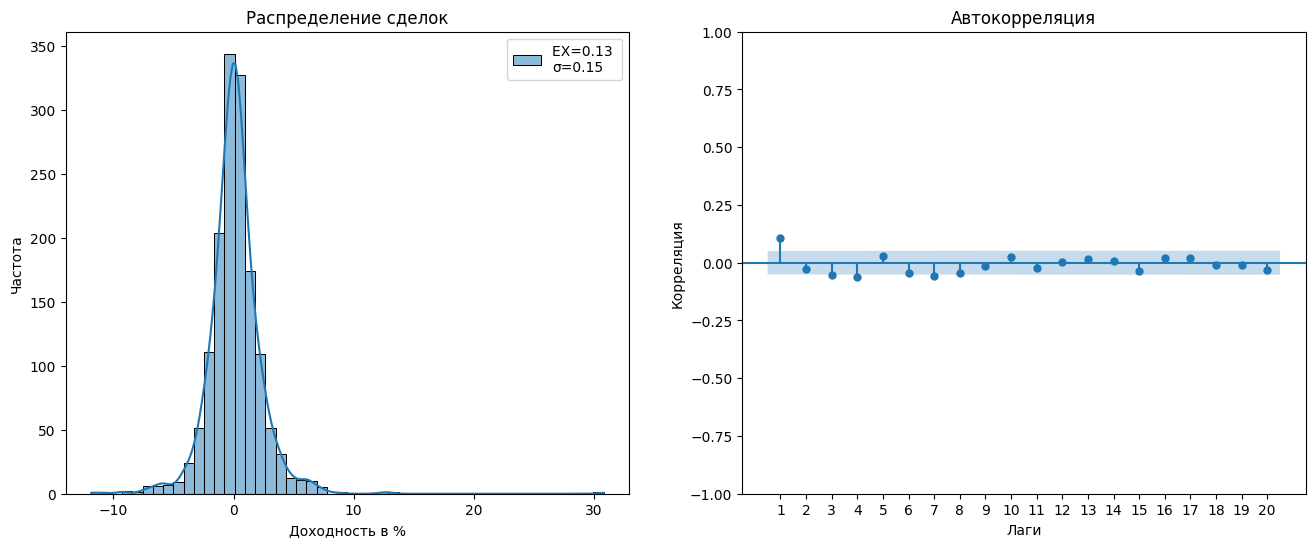

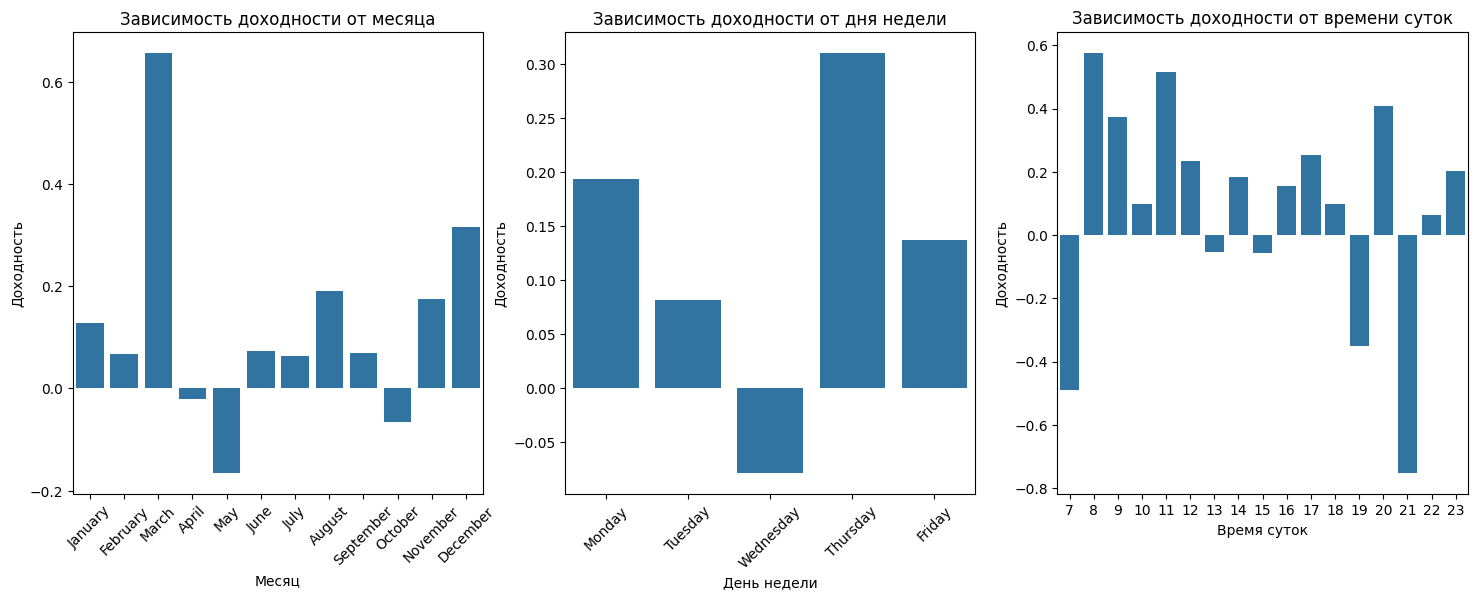

In [15]:
# Функция для глубокого статистического анализа паттернов
def deep_statistics(data, indx):
    """
    Функция предназначена для глубокого статистического анализа торговых стратегий.
    Алгоритм расчитывает:
    - График распределения доходностей и автокорреляцию
    - Проверку на стационарность
    - Проверку на автокорреляцию
    - Проверку на Нормальность
    - Сравнение средней доходности с 0
    - Анализ временных факторов на доходность

    Args:
        data (pd.DataFrame): Датафрейм с результатами стратегий
        indx (int): индекс стратегии
        
    """
    if len(data) > 0:
        pr_percent_net = data.loc[indx, 'profit percent net']
        # 1. График
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        sns.histplot(pr_percent_net * 100, ax=axes[0], bins=50, kde=True, 
                    label=f'EX={np.round(np.mean(pr_percent_net) * 100, 3)} \nσ={np.round(np.sqrt(np.std(pr_percent_net)),3)}')
        axes[0].set_title('Распределение сделок')
        axes[0].set_xlabel('Доходность в %')
        axes[0].set_ylabel('Частота')
        axes[0].legend(fontsize=10)
        plot_acf(pr_percent_net, zero=False, ax=axes[1], lags=20)
        axes[1].set_title('Автокорреляция')
        axes[1].set_xlabel('Лаги')
        axes[1].set_ylabel('Корреляция')
        axes[1].set_xticks(range(1, 21))
        
        # 2. Стационарность
        print('=' * 61)
        print('ТЕСТ ДИКИ-ФУЛЕРА (СТАЦИОНАРНОСТЬ)')
        print('=' * 61)
        result_adfuler = adfuller(pr_percent_net)
        if result_adfuler[1] < 0.05:
            print('Ряд стационарен')
        else:
            print('Ряд нестационарен')
        print()
        
        
        # 3. Тест Льюнг-Бокса
        print('=' * 61)
        print('ТЕСТ ЛЬЮНГ-БОКСА (АВТОКОРРЕЛЯЦИЯ)')
        print('=' * 61)
        lb_test = acorr_ljungbox(pr_percent_net, lags=np.arange(1, 6))
        for i in range(1, 6):
            print(f"Лаг {i}: Наличие автокорреляции - {'Да (p ≤ 0.05)' if lb_test.loc[i, 'lb_pvalue'] <= 0.05 else 'Нет (p > 0.05)'}")
        print()

        # 4. Нормальность распределения
        print('=' * 61)
        print('ТЕСТ НА АНДЕРСОНА-ДАРЛИНГА (НОРМАЛЬНОСТЬ)')
        print('=' * 61)
        Anderson_test = anderson(pr_percent_net, dist='norm')
        for i in range(2, len(Anderson_test.significance_level)):
            sl, cv = Anderson_test.significance_level[i], Anderson_test.critical_values[i]
            print(f'Уровень доверия: {sl}%: {"Нормальное распределение" if Anderson_test.statistic < cv else "Распределение Не нормальное"}')
        print()

        # 5. Сравнение с нулевой доходностью.
        print('=' * 61)
        print('СРАВНЕНИЕ СРЕДНЕГО/МЕДИАНЫ С НУЛЁМ')
        print('=' * 61)
        if Anderson_test.statistic < Anderson_test.critical_values[2]:
            distr = 'YES'
            print(f'СРЕДНЯЯ: {np.round(np.mean(pr_percent_net) * 100, 3)}%')
            _, p_value = stats.ttest_1samp(pr_percent_net, popmean=0)
            if p_value < 0.05:
                zero = 'NO'
                print('Средняя значимо отличается от 0')
            else:
                zero = 'YES'
                print('НЕТ оснований утверждать, что средняя значимо отличается от 0')
        else:
            distr = 'NO'
            print(f'МЕДИАНА: {np.round(np.median(pr_percent_net) * 100, 3)}%')
            _, p_value = wilcoxon(pr_percent_net)
            if p_value < 0.05:
                zero = 'NO'
                print('Медиана значимо отличается от 0')
            else:
                zero = 'YES'
                print('НЕТ оснований утверждать, что медиана значимо отличается от 0')
        print()
        
        # 6. Бутстреп
        print('=' * 61)
        print('БУСТРЕП (95%)')
        print('=' * 61)
        n_trades = len(pr_percent_net)
        list_mean = []
        list_median = []
        for i in range(10_000):
            sample = np.random.choice(pr_percent_net, size=n_trades, replace=True)
            median_sample = np.median(sample)
            mean_sample = np.mean(sample)
            list_median.append(median_sample)
            list_mean.append(mean_sample)
            
        mean_bootstrap = np.round(np.mean(list_mean) * 100, 2) 
        mean_lower = np.round(np.percentile(list_mean, q=2.5) * 100, 2)
        mean_upper = np.round(np.percentile(list_mean, q=97.5) * 100, 2)
        prob_mean = np.round(np.mean(np.array(list_mean) < 0) * 100, 1)
        
        median_bootstrap = np.round(np.median(list_median) * 100, 2)
        median_lower = np.round(np.percentile(list_median, q=2.5) * 100, 2)
        median_upper = np.round(np.percentile(list_median, q=97.5) * 100, 2)
        prob_median = np.round(np.mean(np.array(list_median) < 0) * 100, 1)
        print(f'Средняя:   {mean_bootstrap}%    [{mean_lower}%, {mean_upper}%]. Вероятность убыточности: {prob_mean}%')
        print(f'Медиана:   {median_bootstrap}%  [{median_lower}%, {median_upper}%]. Вероятность убыточности: {prob_median}%')
        
        # 7. Удаление 5% самых больших убытков и 5% самых больших прибылей
        five_upper = np.quantile(pr_percent_net, 0.95)
        five_lower = np.quantile(pr_percent_net, 0.05)
        pr_percent_net_blowout = pr_percent_net[(five_lower < pr_percent_net) & (pr_percent_net < five_upper)]
        # Win rate
        win_rate_n = np.round(np.mean(pr_percent_net > 0) * 100)
        win_rate_blowout = np.round(np.mean(pr_percent_net_blowout > 0) * 100)
        
        # Средние и медианы
        mean_profit_n = np.round(np.mean(pr_percent_net) * 100, 2)
        mean_profit_blowout = np.round(np.mean(pr_percent_net_blowout) * 100, 2)
        median_profit_n = np.round(np.median(pr_percent_net) * 100, 2)
        median_profit_blowout = np.round(np.median(pr_percent_net_blowout) * 100, 2)
        
        # Профит фактор
        profit_factor_n = np.round(np.sum(pr_percent_net[pr_percent_net > 0]) / np.abs(np.sum(pr_percent_net[pr_percent_net < 0])), 2)
        profit_factor_blowout = np.round(np.sum(pr_percent_net_blowout[pr_percent_net_blowout > 0]) / np.abs(np.sum(pr_percent_net_blowout[pr_percent_net_blowout < 0])), 2)
        
        # Сравнение с нулевой доходностью
        Anderson_test_blowout = anderson(pr_percent_net_blowout, dist='norm')
        if Anderson_test_blowout.statistic < Anderson_test_blowout.critical_values[2]:
            distr_blowout = 'YES'
            _, p_value_b = stats.ttest_1samp(pr_percent_net_blowout, popmean=0)
            if p_value_b < 0.05:
                zero_b = 'NO'
            else:
                zero_b = 'YES'
        else:
            distr_blowout = 'NO'
            _, p_value_b = wilcoxon(pr_percent_net_blowout)
            if p_value_b < 0.05:
                zero_b = 'NO'
            else:
                zero_b = 'YES'
        print()
        
        # Собираем всё вместе в табличку
        dict_normal = {'winrate (%)' : win_rate_n, 'mean return (%)' : mean_profit_n, 'median return (%)' : median_profit_n, 
                    'profit factor' : profit_factor_n,
                    'Normal dist?' : distr, 'p-value (= 0?)' : np.round(p_value, 3), '= 0?' : zero}
        dict_blowout = {'winrate (%)' : win_rate_blowout, 'mean return (%)' : mean_profit_blowout, 'median return (%)' : median_profit_blowout, 
                        'profit factor' : profit_factor_blowout,
                    'Normal dist?' : distr_blowout, 'p-value (= 0?)' : np.round(p_value_b, 3), '= 0?' : zero_b}
        df = pd.DataFrame({'Normal' : dict_normal, 'Without outliers' : dict_blowout})
        display(df)
        

        # 6 Временной анализ
        data_percent = (pr_percent_net * 100).to_frame().reset_index()
        data_percent['time_N'] = pd.to_datetime(data_percent['time_N'])
        data_percent['Month'] = data_percent['time_N'].dt.month_name()
        data_percent['day_of_week'] = data_percent['time_N'].dt.day_name()
        data_percent['hour'] = data_percent['time_N'].dt.hour
        
        # Группировка
        months = ['January', 'February', 'March', 'April', 'May', 'June',
            'July', 'August', 'September', 'October', 'November', 'December']
        weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
        data_percent_group_month = data_percent.groupby('Month')['profit_percent_net'].mean().reset_index()
        data_percent_group_day_of_week = data_percent.groupby('day_of_week')['profit_percent_net'].mean().reset_index()
        data_percent_group_hour = data_percent.groupby('hour')['profit_percent_net'].mean().reset_index()
        
        # График 
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # 1
        sns.barplot(data_percent_group_month, x=data_percent_group_month['Month'], y=data_percent_group_month['profit_percent_net'], ax=axes[0],
                    order=months)
                    
        axes[0].set_title('Зависимость доходности от месяца')
        axes[0].set_xlabel('Месяц')
        axes[0].set_ylabel('Доходность')
        axes[0].set_xticklabels(labels=months, rotation=45)
        
        # 2
        sns.barplot(data_percent_group_day_of_week, x=data_percent_group_day_of_week['day_of_week'], y=data_percent_group_day_of_week['profit_percent_net'], ax=axes[1],
                    order=weekdays)
        axes[1].set_title('Зависимость доходности от дня недели')
        axes[1].set_xlabel('День недели')
        axes[1].set_ylabel('Доходность')
        axes[1].set_xticklabels(labels=weekdays, rotation=45)
        
        # 3
        sns.barplot(data_percent_group_hour, x=data_percent_group_hour['hour'], y=data_percent_group_hour['profit_percent_net'], ax=axes[2])
        axes[2].set_title('Зависимость доходности от времени суток')
        axes[2].set_xlabel('Время суток')
        axes[2].set_ylabel('Доходность')
    else:
        print('ХОРОШИХ СТРАТЕГИЙ НЕТ')

    
result_statistics = deep_statistics(res, 2)

### Сводная статистика
|           | Паттерн              | Период | N | PR | (=0?) | (Бустреп) |
|-----------|---------              |--------|---|----|-------|-----------|
|      1     |    бычья контратака  |   1 h     | 10  |   1.238 |   YES/YES    |   1.3%/37.9%        |
|     2      |    бычья контратака       |   15 min    | 35  |  1.151  |    YES/YES   |     2.5%/33.3%      |
|      3     |    бычье поглощение  |  30 min      |  20 |  1.195  |   NO/NO    |   1.1%/2.8%        |

### Каждая из стратегий показывает неплохие результаты, хоть и не проходит тест на равенство 0. Возьмём эти 3 стратегии для дальнейшего улучшения.

In [16]:
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_tatneft.pkl', 'wb') as file:
    pickle.dump(res, file)